# EDA Tuberculósis

**DIEGO BESADA RODRÍGUEZ**

<div>
  <img src="images/tuberculosis.jpg"
       alt="Tuberculosis"
       width="200">
</div>

<br>

<div style="border:2px solid lightgreen; padding:10px; border-radius:5px; background-color:#ECFEEA;">
<strong>Estado:</strong> Terminado.
</div>

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [2]:
import warnings
warnings.filterwarnings("ignore")

## PARTE 1: Rehacer Notebooks

Este notebook comienza con una sección en la que se rehacen todos los gráficos encontrados en los notebooks de EDA de la tuberculosis (Datasets/EDA_Tuberculosis) con la librería plotly en lugar de matplotlib. La explicación de estas visualizaciones se puede encontrar en dichos notebooks. En la secciones posteriores a esta se volvera a explicar con detalle qué se esta resolviendo y el porqué de la metodología.

In [3]:
deaths = pd.read_csv("Datasets/EDA_Tuberculosis/datasets/tb_deaths_100.csv", index_col=0, thousands=',').T
existing = pd.read_csv("Datasets/EDA_Tuberculosis/datasets/tb_existing_100.csv", index_col=0, thousands=',').T
new = pd.read_csv("Datasets/EDA_Tuberculosis/datasets/tb_new_100.csv", index_col=0, thousands=',').T

In [4]:
total_deaths = deaths.sum(axis=1)
total_existing = existing.sum(axis=1)
total_new = new.sum(axis=1)

In [5]:
fig = px.line(
    existing.reset_index(),
    x=existing.index.name if existing.index.name else "index",
    y=["United Kingdom", "Spain", "Colombia"],
    markers=True,
    title="TB prevalence (por 100k): UK, Spain, Colombia",
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Year",
    yaxis_title="Casos por 100k",
    hovermode='x unified'
)

fig.update_xaxes(showgrid=True)
fig.update_yaxes(showgrid=True)

fig.show()

In [6]:
box_df = existing[["United Kingdom", "Spain", "Colombia"]].reset_index().melt(
    id_vars=existing.index.name if existing.index.name else "index",
    var_name="País",
    value_name="Casos por 100k"
)

fig = px.box(
    box_df,
    x="País",
    y="Casos por 100k",
    color="País",
    # points="all",
    title="Distribución TB (por 100k): UK, Spain, Colombia"
)

fig.update_layout(template="plotly_white", showlegend=False)
fig.show()

In [7]:
world_trends = pd.DataFrame({
           'Total deaths per 100K' : total_deaths,
           'Total existing cases per 100K' : total_existing,
           'Total new cases per 100K' : total_new},
       index=total_deaths.index)

In [8]:
world_trends_reset = world_trends.reset_index().rename(columns={'index': 'Year'})
world_trends_melted = world_trends_reset.melt(id_vars='Year', var_name='Type', value_name='Cases per 100K')
world_trends_melted['Year'] = world_trends_melted['Year'].astype(str)

fig = px.line(
    world_trends_melted,
    x='Year',
    y='Cases per 100K',
    color='Type',
    title='World Trends in TB Cases (1990-2007)',
    markers=True,
    hover_name='Type',
    labels={'Year': 'Year', 'Cases per 100K': 'Cases per 100K'}
)

fig.update_layout(
    hovermode='x unified',
    height=500,
    template='plotly_white',
    font=dict(size=12)
)

fig.show()

In [9]:
deaths_by_country_mean = deaths.mean()
deaths_sorted = deaths_by_country_mean.sort_values()
deaths_bar_df = pd.DataFrame({
    'Country': deaths_sorted.index,
    'Deaths per 100K (Mean)': deaths_sorted.values
})

fig = px.bar(
    deaths_bar_df,
    x='Deaths per 100K (Mean)',
    y='Country',
    title='Average TB Deaths by Country (1990-2007)',
    orientation='h',
    height=800
)

fig.update_layout(
    hovermode='closest',
    template='plotly_white',
    font=dict(size=10)
)

fig.show()

** Nótese que en la leyenda no aparecen todos los países, compruebese el país pasando el cursor por encima del gráfico.

In [10]:
new_by_country_mean = new.mean()
new_by_country_mean_summary = new_by_country_mean.describe()
new_super_outlier = new_by_country_mean_summary['50%'] * 5
super_outlier_countries_by_new = new_by_country_mean > new_super_outlier
super_outlier_new_df = new.T[super_outlier_countries_by_new].T
super_outlier_new_reset = super_outlier_new_df.reset_index().rename(columns={'index': 'Year'})
super_outlier_new_melted = super_outlier_new_reset.melt(id_vars='Year', var_name='Country', value_name='New Cases per 100K')
super_outlier_new_melted['Year'] = super_outlier_new_melted['Year'].astype(str)

fig = px.line(
    super_outlier_new_melted,
    x='Year',
    y='New Cases per 100K',
    color='Country',
    title='New TB Cases in Super Outlier Countries (5x IQR)',
    markers=True,
    height=600
)

fig.update_layout(
    template='plotly_white',
    font=dict(size=10)
)

fig.show()

In [11]:
super_outlier_countries_by_new_index = new_by_country_mean > new_super_outlier

average_super_outlier_country = new.loc[:, super_outlier_countries_by_new_index].mean(axis=1)
avearge_better_world_country = new.loc[:, ~super_outlier_countries_by_new_index].mean(axis=1)

two_world_df = pd.DataFrame({
    "Average Better World Country": avearge_better_world_country,
    "Average Outlier Country": average_super_outlier_country
}, index=new.index)

two_world_plot_df = (
    two_world_df
    .rename_axis("Year")
    .reset_index()
    .melt(id_vars="Year", var_name="Group", value_name="Estimated new TB cases per 100K")
)

fig = px.line(
    two_world_plot_df,
    x="Year",
    y="Estimated new TB cases per 100K",
    color="Group",
    markers=True,
    title="Estimated new TB cases per 100K"
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    width=1000,
    height=550
)

fig.show()

In [12]:
pct_df = (
    two_world_df
    .pct_change()
    .mul(100)
    .reset_index()
    .rename(columns={two_world_df.index.name if two_world_df.index.name else "index": "Year"})
    .melt(id_vars="Year", var_name="Group", value_name="Percentage change")
)

fig = px.line(
    pct_df,
    x="Year",
    y="Percentage change",
    color="Group",
    markers=True,
    title="Percentage change in estimated new TB cases"
)

fig.update_layout(
    template="plotly_white",
    width=1000,
    height=550,
    hovermode="x unified"
)

fig.update_yaxes(ticksuffix="%")
fig.show()

In [13]:
fig = px.line(
    x=existing.index,
    y=existing["China"],
    title="Estimated existing TB cases in China",
    labels={"x": "Year", "y": "Cases per 100K"},
    markers=True
)

fig.update_layout(template="plotly_white")
fig.update_xaxes(showgrid=True)
fig.update_yaxes(showgrid=True)

fig.show()

In [14]:
existing_df = pd.read_csv('Datasets/EDA_Tuberculosis/datasets/tb_existing_100.csv', index_col = 0, thousands  = ',')
existing_df.index.names = ['country']
existing_df.columns.names = ['year']

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(existing_df)
existing_2d = pca.transform(existing_df)

In [16]:
existing_df_2d = pd.DataFrame(existing_2d)
existing_df_2d.index = existing_df.index
existing_df_2d.columns = ['PC1','PC2']
existing_df_2d.head()

,PC1,PC2
country,,
Afghanistan,732.215864,203.381494
Albania,-613.296510,4.715978
Algeria,-569.303713,-36.837051
American Samoa,-717.082766,5.464696
Andorra,-661.802241,11.037736


In [17]:
pca_plot_df = existing_df_2d.reset_index().rename(columns={"country": "País"})

fig = px.scatter(
    pca_plot_df,
    x="PC2",
    y="PC1",
    text="País",
    hover_name="País",
    title="PCA de países (PC1 vs PC2)"
)

fig.update_traces(
    textposition="top center",
    marker=dict(size=7, opacity=0.75)
)

fig.update_layout(
    template="plotly_white",
)

fig.show()

In [18]:
from sklearn.preprocessing import normalize

existing_df_2d['country_mean'] = pd.Series(existing_df.mean(axis=1), index=existing_df_2d.index)
country_mean_max = existing_df_2d['country_mean'].max()
country_mean_min = existing_df_2d['country_mean'].min()
country_mean_scaled = (existing_df_2d.country_mean-country_mean_min) / country_mean_max
existing_df_2d['country_mean_scaled'] = pd.Series(
    country_mean_scaled,
    index=existing_df_2d.index)
existing_df_2d.head()

plot_df = existing_df_2d.reset_index().rename(columns={"country": "País"})

fig = px.scatter(
    plot_df,
    x="PC2",
    y="PC1",
    size="country_mean_scaled",
    size_max=10,
    hover_name="País",
    title="PCA (PC2 vs PC1) con tamaño según media de casos TB",
    labels={"PC2": "PC2", "PC1": "PC1", "country_mean_scaled": "Media (escalada)"}
)

fig.update_traces(marker=dict(opacity=0.75, line=dict(width=0.5, color="white")))
fig.update_layout(template="plotly_white", width=1100, height=550)

fig.show()

In [19]:
existing_df_2d['country_sum'] = pd.Series(existing_df.sum(axis=1), index=existing_df_2d.index)
country_sum_max = existing_df_2d['country_sum'].max()
country_sum_min = existing_df_2d['country_sum'].min()
country_sum_scaled = (existing_df_2d.country_sum-country_sum_min) / country_sum_max
existing_df_2d['country_sum_scaled'] = pd.Series(
    country_sum_scaled,
    index=existing_df_2d.index)


plot_sum_df = existing_df_2d.reset_index().rename(
    columns={existing_df_2d.index.name if existing_df_2d.index.name else "index": "País"}
)

fig = px.scatter(
    plot_sum_df,
    x="PC2",
    y="PC1",
    size="country_sum_scaled",
    size_max=10,
    hover_name="País",
    title="PCA (PC2 vs PC1) con tamaño según suma de casos TB",
    labels={"country_sum_scaled": "Suma (escalada)"}
)

fig.update_traces(marker=dict(opacity=0.75, line=dict(width=0.5, color="white")))
fig.update_layout(template="plotly_white")

fig.show()

In [20]:
existing_df_2d['country_change'] = pd.Series(existing_df['2007']-existing_df['1990'], index=existing_df_2d.index)
country_change_max = existing_df_2d['country_change'].max()
country_change_min = existing_df_2d['country_change'].min()
country_change_scaled = (existing_df_2d.country_change - country_change_min) / country_change_max
existing_df_2d['country_change_scaled'] = pd.Series(
    country_change_scaled,
    index=existing_df_2d.index)
existing_df_2d[['country_change','country_change_scaled']].head()

plot_change_df = existing_df_2d.reset_index().rename(
    columns={existing_df_2d.index.name if existing_df_2d.index.name else "index": "País"}
)

fig = px.scatter(
    plot_change_df,
    x="PC2",
    y="PC1",
    size="country_change_scaled",
    size_max=10,
    hover_name="País",
    title="PCA (PC2 vs PC1) con tamaño según cambio 2007-1990",
    labels={"country_change_scaled": "Cambio escalado", "PC2": "PC2", "PC1": "PC1"}
)

fig.update_traces(marker=dict(opacity=0.75, line=dict(width=0.5, color="white")))
fig.update_layout(template="plotly_white", width=1100, height=550)

fig.show()

In [21]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5)
clusters = kmeans.fit(existing_df)

existing_df_2d['cluster'] = pd.Series(clusters.labels_, index=existing_df_2d.index)

plot_cluster_df = existing_df_2d.reset_index().rename(
    columns={existing_df_2d.index.name if existing_df_2d.index.name else "index": "País"}
)
plot_cluster_df["cluster"] = plot_cluster_df["cluster"].astype(str)

fig = px.scatter(
    plot_cluster_df,
    x="PC2",
    y="PC1",
    color="cluster",
    hover_name="País",
    title="KMeans (k=5) sobre PCA (PC2 vs PC1)",
    labels={"PC2": "PC2", "PC1": "PC1", "cluster": "Cluster"},
)

fig.update_traces(marker=dict(size=8, opacity=0.8, line=dict(width=0.5, color="white")))
fig.update_layout(template="plotly_white")

fig.show()

## PARTE 2: Cuestiones de ejemplo

### Distribución de casos en el 2000 por continente

In [22]:
def map_cases_by_scope(df, scope):
    df = df.loc['2000']

    map_df = (
        df
        .rename_axis("País")
        .reset_index(name="Casos por 100k")
    )

    map_df["País"] = map_df["País"].str.title()

    fig = px.choropleth(
        map_df,
        locations="País",
        locationmode="country names",
        color="Casos por 100k",
        hover_name="País",
        color_continuous_scale="Reds",
        projection="equirectangular",
        title=f"<b>Mapa de {scope.title()} de casos de tuberculosis (2000)</b>"
    )

    fig.update_geos(
        showcountries=True,
        showcoastlines=True,
        showframe=False,
        scope=scope
    )

    fig.update_layout(
        title_x=0.5,
        title_xanchor="center",
        margin=dict(l=0, r=0, t=50, b=0),
        dragmode=False
    )

    fig.show(config={"scrollZoom": False})

In [23]:
for scope in ["europe", "asia", "africa", "north america", "south america"]:
    map_cases_by_scope(existing, scope)

Se usa un mapa de calor porque la pregunta es espacial: no solo importa cuánto tuberculosis hay, sino dónde se concentra. Al codificar los casos con una escala de color, se puede ver de un vistazo qué zonas tienen mayor carga y cuáles menor, sin leer país por país. Este tipo de visualización facilita comparar muchos territorios al mismo tiempo, detectar patrones regionales, identificar focos críticos y comunicar mejor la desigualdad geográfica de la enfermedad en un año concreto como el 2000.

### Ranking de paises con más tuberculosis dado un año

In [24]:
existing.index.name = "year"
new.index.name = "year"
deaths.index.name = "year"

df_existing = existing.reset_index().melt(id_vars="year", var_name="País", value_name="Casos")
df_existing["Tipo"] = "existing"

df_new = new.reset_index().melt(id_vars="year", var_name="País", value_name="Casos")
df_new["Tipo"] = "new"

df_deaths = deaths.reset_index().melt(id_vars="year", var_name="País", value_name="Casos")
df_deaths["Tipo"] = "deaths"

df_combined = pd.concat([df_existing, df_new, df_deaths], ignore_index=True)

df_top10 = (
    df_combined.sort_values(["year", "Tipo", "Casos"], ascending=[True, True, False])
    .groupby(["year", "Tipo"]) 
    .head(10)
    .reset_index(drop=True)
)

top_countries_order = (
    df_top10.groupby("País")["Casos"].sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

df_top10["País"] = pd.Categorical(df_top10["País"], categories=top_countries_order, ordered=True)

In [25]:
def plot_top_por_tipo(tipo="deaths", top=10):
    tipo = tipo.strip().lower()
    tipos_validos = sorted(df_top10["Tipo"].unique().tolist())

    if tipo not in tipos_validos:
        raise ValueError(f"Tipo inválido: '{tipo}'. Usa uno de: {tipos_validos}")

    years = sorted(df_top10["year"].unique())
    color_map = {"existing": "turquoise", "new": "orange", "deaths": "red"}

    max_casos_tipo = df_top10.loc[df_top10["Tipo"] == tipo, "Casos"].max()
    x_max = float(max_casos_tipo) * 1.05

    fig = go.Figure()

    for year in years:
        df_year = (
            df_top10[(df_top10["Tipo"] == tipo) & (df_top10["year"] == year)]
            .nlargest(top, "Casos")
            .sort_values("Casos", ascending=False)
        )

        fig.add_trace(
            go.Bar(
                x=df_year["Casos"],
                y=df_year["País"],
                orientation="h",
                visible=False,
                name=f"{tipo} {year}",
                marker_color=color_map.get(tipo, "gray"),
            )
        )

    fig.data[0].visible = True

    steps = []
    for i, year in enumerate(years):
        visible = [False] * len(fig.data)
        visible[i] = True

        steps.append(
            dict(
                label=str(year),
                method="update",
                args=[
                    {"visible": visible},
                    {"title": f"<b>Top 10 países ({tipo}) - Año {year}</b>"},
                ],
            )
        )

    fig.update_layout(
        sliders=[dict(active=0, currentvalue={"prefix": "Año: "}, pad={"t": 50}, steps=steps)],
        xaxis=dict(range=[0, x_max]),  # <- rango fijo
        yaxis=dict(autorange="reversed"),
        margin=dict(l=120, r=150, t=100, b=50),
        title=f"<b>Top 10 países ({tipo}) - Año {years[0]}</b>",
        title_x=0.5,
    )

    fig.show(config={"scrollZoom": False})

In [26]:
for tipo in sorted(df_top10["Tipo"].unique()):
    plot_top_por_tipo(tipo, top=10)

Se usa un gráfico de barras porque la pregunta busca comparar magnitudes entre países y construir un ranking claro en un año concreto. Las barras permiten ver de inmediato qué países tienen más casos, cuánto se separan entre sí y en qué orden quedan, algo que otras visualizaciones hacen menos legible cuando hay muchas categorías. Además, al usar barras horizontales, los nombres de países se leen mejor y se facilita identificar rápidamente el top 10 sin ambigüedad.

### Ranking de paises con más incidencia tuberculosis

In [27]:
total_deaths_per_country = deaths.sum()
total_existing_per_country = existing.sum()
total_new_per_country = new.sum()

top10_series = {
    "Deaths": total_deaths_per_country.sort_values(ascending=False).head(20),
    "Existing": total_existing_per_country.sort_values(ascending=False).head(20),
    "New": total_new_per_country.sort_values(ascending=False).head(20),
}

color_map = {
    "Deaths": "crimson",
    "Existing": "royalblue",
    "New": "darkorange",
}

top10_df = pd.concat(
    [
        s.rename("Casos acumulados (1990-2007)")
         .rename_axis("País")
         .reset_index()
         .assign(Tipo=tipo)
        for tipo, s in top10_series.items()
    ],
    ignore_index=True
)

tipos = list(top10_series.keys())
x_max = top10_df["Casos acumulados (1990-2007)"].max() * 1.1

fig = go.Figure()

for i, tipo in enumerate(tipos):
    df_tipo = (
        top10_df[top10_df["Tipo"] == tipo]
        .sort_values("Casos acumulados (1990-2007)", ascending=True)
    )

    fig.add_trace(
        go.Bar(
            x=df_tipo["Casos acumulados (1990-2007)"],
            y=df_tipo["País"],
            orientation="h",
            marker_color=color_map[tipo],
            name=tipo,
            visible=(i == 0),
        )
    )

buttons = []
for i, tipo in enumerate(tipos):
    visible = [False] * len(tipos)
    visible[i] = True
    buttons.append(
        dict(
            label=tipo,
            method="update",
            args=[
                {"visible": visible},
                {"title": f"Top 10 países - {tipo}"}
            ],
        )
    )

fig.update_layout(
    template="plotly_white",
    height=500,
    title=f"Top 10 países - {tipos[0]}",
    xaxis_title="Casos acumulados (1990-2007)",
    yaxis_title="País",
    # xaxis=dict(range=[0, x_max]),
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=1.02,
            y=1,
            xanchor="left",
            yanchor="top",
            showactive=True
        )
    ],
    margin=dict(l=120, r=180, t=70, b=50)
)

fig.show()


Se usa un gráfico de barras porque la pregunta busca comparar magnitudes entre países y construir un ranking claro en un año concreto. Las barras permiten ver de inmediato qué países tienen más casos, cuánto se separan entre sí y en qué orden quedan, algo que otras visualizaciones hacen menos legible cuando hay muchas categorías. Además, al usar barras horizontales, los nombres de países se leen mejor y se facilita identificar rápidamente el top 10 sin ambigüedad.

### PCA: Análisis del punto Zimbabwe

En esta muestra, Zimbabwe no es el punto más extremo del plaño PCA. Debemos darnos cuenta de que estamos utilizando el dataset 'existing', donde Zimbabwe ocupa la posicion número 18. Lo primero que vamos a calcular es la distancia al centro (usando la mediana puesto que la presencia de outliers distorsiona la media).

In [28]:
pca_plot_df = existing_df_2d.reset_index().rename(columns={"country": "País"}).copy()

med_pc1 = pca_plot_df["PC1"].median()
med_pc2 = pca_plot_df["PC2"].median()

pca_plot_df["dist_mediana"] = np.sqrt(
    (pca_plot_df["PC1"] - med_pc1) ** 2 + (pca_plot_df["PC2"] - med_pc2) ** 2
)

ranking_mediana = pca_plot_df[["País", "PC1", "PC2", "dist_mediana"]].sort_values("dist_mediana", ascending=False)
pos_zimbabwe_med = int(
    ranking_mediana.reset_index(drop=True).query("País == 'Zimbabwe'").index[0]
) + 1

print(f"Posición de Zimbabwe por distancia euclídea a la mediana: {pos_zimbabwe_med}")
display(ranking_mediana.head(20))

Posición de Zimbabwe por distancia euclídea a la mediana: 17


,País,PC1,PC2,dist_mediana
54,Djibouti,3798.447446,578.975277,4248.011841
32,Cambodia,2538.953258,223.864004,2957.493141
96,Kiribati,2234.809790,864.494075,2782.058185
51,"Korea, Dem. Rep.",2146.623299,438.945977,2593.885303
162,Sierra Leone,1986.283717,-711.011060,2500.352442
181,Togo,2082.653641,-181.824054,2499.646087
143,Philippines,1971.702345,337.221038,2405.374120
173,Swaziland,1924.120149,-565.553334,2402.368433
22,Bhutan,1742.709249,569.448954,2226.420191
168,South Africa,1785.056105,-109.857000,2198.125358


Puede verse que las distancias al centro del PCA son muy similares al ranking de países con más casos acumulados. Esto ocurre porque el PCA se ha aplicado sobre valores absolutos del dataset `existing`, de modo que la primera componente principal está muy influida por la magnitud total de casos.

En consecuencia, los países con mayor carga global de TB tienden a aparecer también como los más alejados del centro en el plaño PCA. En este contexto, Zimbabwe no es el outlier principal, aunque sí aparece relativamente separado del núcleo central.

In [29]:
ranking_mediana = (
    pca_plot_df[["País", "PC1", "PC2", "dist_mediana"]]
    .sort_values("dist_mediana", ascending=False)
)

pos_zimbabwe_med = int(
    ranking_mediana.reset_index(drop=True).query("País == 'Zimbabwe'").index[0]
) + 1

center_pc1 = med_pc1 if "med_pc1" in globals() else pca_plot_df["PC1"].median()
center_pc2 = med_pc2 if "med_pc2" in globals() else pca_plot_df["PC2"].median()

fig = px.scatter(
    pca_plot_df,
    x="PC2",
    y="PC1",
    color="dist_mediana",
    color_continuous_scale="YlOrRd",
    hover_name="País",
    hover_data={
        "PC1": ":.2f",
        "PC2": ":.2f",
        "dist_mediana": ":.2f",
    },
    title="PCA con gradiente por distancia euclídea a la mediana",
    labels={"dist_mediana": "Distancia a mediana"},
)

fig.update_traces(marker=dict(size=8, opacity=0.85, line=dict(width=0)))
fig.update_layout(template="plotly_white")

row_zim = pca_plot_df[pca_plot_df["País"] == "Zimbabwe"].iloc[0]
fig.add_trace(
    go.Scatter(
        x=[row_zim["PC2"]],
        y=[row_zim["PC1"]],
        mode="markers+text",
        text=[f"Zimbabwe (puesto {pos_zimbabwe_med})"],
        textposition="top center",
        marker=dict(size=13, color="rgba(0,0,0,0)", line=dict(color="black", width=2)),
        showlegend=False,
        hoverinfo="skip",
    )
)

fig.add_trace(
    go.Scatter(
        x=[center_pc2],
        y=[center_pc1],
        mode="markers+text",
        text=["Mediana"],
        textposition="bottom right",
        marker=dict(symbol="x", size=14, color="black", line=dict(width=2)),
        showlegend=False,
        hovertemplate="PC2=%{x:.2f}<br>PC1=%{y:.2f}<extra></extra>",
    )
)

fig.show()

### ¿Es buena selección 5 clusters?


k=5 era una elección exploratoria que no estaba basada en ninguna métrica. Por ello, evaluamos distintos valores de k (de 2 a 10) con tres criterios: `silhouette_score`, `calinski_harabasz_score` y `davies_bouldin_score`.

In [30]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from plotly.subplots import make_subplots

X_pca = existing_df_2d[["PC1", "PC2"]].copy()

silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []
k_values = list(range(2, 11))

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)

    silhouette_scores.append(silhouette_score(X_pca, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_pca, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_pca, labels))

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Silhouette Score (max)", "Calinski-Harabasz Score (max)", "Davies-Bouldin Score (min)")
)

fig.add_trace(
    go.Scatter(
        x=k_values,
        y=silhouette_scores,
        mode="lines+markers",
        marker=dict(size=9),
        line=dict(width=2),
        showlegend=False,
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=k_values,
        y=calinski_harabasz_scores,
        mode="lines+markers",
        marker=dict(size=9, symbol="square"),
        line=dict(width=2),
        showlegend=False,
    ),
    row=1,
    col=2,
)

fig.add_trace(
    go.Scatter(
        x=k_values,
        y=davies_bouldin_scores,
        mode="lines+markers",
        marker=dict(size=9, symbol="diamond"),
        line=dict(width=2),
        showlegend=False,
    ),
    row=1,
    col=3,
)

fig.update_xaxes(title_text="Número de clusters (k)", tickmode="array", tickvals=k_values, row=1, col=1)
fig.update_xaxes(title_text="Número de clusters (k)", tickmode="array", tickvals=k_values, row=1, col=2)
fig.update_xaxes(title_text="Número de clusters (k)", tickmode="array", tickvals=k_values, row=1, col=3)

fig.update_yaxes(title_text="Score", row=1, col=1)
fig.update_yaxes(title_text="Score", row=1, col=2)
fig.update_yaxes(title_text="Score", row=1, col=3)

fig.update_layout(
    template="plotly_white",
    title_text="Evaluación de KMeans sobre espacio PCA (PC1, PC2)",
    title_x=0.5,
)

fig.show()

Con la evaluación realizada (Silhouette, Calinski-Harabasz y Davies-Bouldin) se obtiene:

- Mejor k por Silhouette: 2
- Mejor k por Calinski-Harabasz: 10
- Mejor k por Davies-Bouldin: 2

Los datos sugieren que k=2 es la selección más robusta según dos de las tres métricas evaluadas. 

In [31]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("KMeans (k=2) sobre PCA (PC2 vs PC1)", "KMeans (k=5) sobre PCA (PC2 vs PC1)"),
    specs=[[{"type": "scatter"}, {"type": "scatter"}]]
)

kmeans_2 = KMeans(n_clusters=2, n_init=10)
kmeans_2.fit(existing_df)
plot_cluster_df_2 = existing_df_2d.reset_index().rename(
    columns={existing_df_2d.index.name if existing_df_2d.index.name else "index": "País"}
).copy()
plot_cluster_df_2["cluster"] = kmeans_2.labels_
plot_cluster_df_2["cluster"] = plot_cluster_df_2["cluster"].astype(str)

kmeans_5 = KMeans(n_clusters=5, n_init=10)
kmeans_5.fit(existing_df)
plot_cluster_df_5 = existing_df_2d.reset_index().rename(
    columns={existing_df_2d.index.name if existing_df_2d.index.name else "index": "País"}
).copy()
plot_cluster_df_5["cluster"] = kmeans_5.labels_
plot_cluster_df_5["cluster"] = plot_cluster_df_5["cluster"].astype(str)

for cluster in sorted(plot_cluster_df_2["cluster"].unique()):
    data = plot_cluster_df_2[plot_cluster_df_2["cluster"] == cluster]
    fig.add_trace(
        go.Scatter(
            x=data["PC2"],
            y=data["PC1"],
            mode="markers",
            name=f"Cluster {cluster}",
            marker=dict(size=8, opacity=0.8),
            legendgroup="k2",
            showlegend=True,
            hovertext=data["País"]
        ),
        row=1, col=1
    )

for cluster in sorted(plot_cluster_df_5["cluster"].unique()):
    data = plot_cluster_df_5[plot_cluster_df_5["cluster"] == cluster]
    fig.add_trace(
        go.Scatter(
            x=data["PC2"],
            y=data["PC1"],
            mode="markers",
            name=f"Cluster {cluster}",
            marker=dict(size=8, opacity=0.8),
            legendgroup="k5",
            showlegend=False,
            hovertext=data["País"]
        ),
        row=1, col=2
    )

fig.update_xaxes(title_text="PC2", row=1, col=1)
fig.update_xaxes(title_text="PC2", row=1, col=2)
fig.update_yaxes(title_text="PC1", row=1, col=1)
fig.update_yaxes(title_text="PC1", row=1, col=2)

fig.update_layout(template="plotly_white")
fig.show()

Ademas de en la evaluación de clustering (Silhouette, Calinski-Harabasz y Davies-Bouldin) podemos visualizar que dos clusteres tienen más sentido que 5 para este problema. La información que nos otorga que un punto pertenezca a un grupo o al otro no queda del todo clara aunque parece tener cierta relación con: enfermedad controlada y enfermedad descontrolada.

## PARTE 3: Cuestiones adicionales

In [32]:
# Setup de PARTE 3: tablas limpias y mapeo pais->continente
from plotly.subplots import make_subplots

YEARS = sorted([str(c) for c in existing.index])

def to_long(df_wide, value_name):
    out = (
        df_wide.copy()
        .rename_axis("year")
        .reset_index()
        .melt(id_vars="year", var_name="country", value_name=value_name)
    )
    out["year"] = out["year"].astype(str)
    out[value_name] = pd.to_numeric(out[value_name], errors="coerce")
    return out.dropna(subset=[value_name])

existing_long = to_long(existing, "existing_per100k")
new_long = to_long(new, "new_per100k")
deaths_long = to_long(deaths, "deaths_per100k")

df = (
    existing_long
    .merge(new_long, on=["year", "country"], how="inner")
    .merge(deaths_long, on=["year", "country"], how="inner")
)

df["cfr_proxy"] = np.where(df["new_per100k"] > 0, df["deaths_per100k"] / df["new_per100k"], np.nan)

gapminder_map = px.data.gapminder()[["country", "continent"]].drop_duplicates()
country_name_fixes = {
    "Korea, Dem. Rep.": "Korea, Dem. Rep.",
    "Korea, Rep.": "Korea, Rep.",
    "Russian Federation": "Russia",
    "Egypt, Arab Rep.": "Egypt",
    "Iran, Islamic Rep.": "Iran",
    "Venezuela, RB": "Venezuela",
    "Yemen, Rep.": "Yemen, Rep.",
    "Slovak Republic": "Slovak Republic",
    "Kyrgyz Republic": "Kyrgyz Republic",
}

df["country_for_map"] = df["country"].replace(country_name_fixes)
df = df.merge(
    gapminder_map.rename(columns={"country": "country_for_map"}),
    on="country_for_map",
    how="left"
)

### ¿Cómo varió la brecha de salud entre el país más afectado y el menos afectado entre 1990 y 2007?

In [33]:
gap_year = (
    df.groupby("year")["existing_per100k"]
    .agg(max_case="max", min_case="min")
    .reset_index()
)
gap_year["gap_abs"] = gap_year["max_case"] - gap_year["min_case"]

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(
        x=gap_year["year"],
        y=gap_year["gap_abs"],
        mode="lines+markers",
        name="Brecha entre paises (max-min)",
        line=dict(color="crimson", width=3),
    ),
    secondary_y=False,
)

fig.update_layout(
    template="plotly_white",
    title="Brecha (max-min)",
)
fig.update_yaxes(title_text="Brecha absoluta", secondary_y=False)
fig.update_yaxes(title_text="Brecha relativa (ratio)", secondary_y=True)
fig.update_xaxes(title_text="Ano")
fig.show()

El gráfico superior muestra la evolución anual de la brecha de tuberculosis entre países (tomando, para cada año, el país con más casos y el país con menos casos en existing_per100k). 

La línea representa la brecha absoluta `max - min` por año (la relativa se ha omitido puesto que el minimo en muchos años es 0). Se observa en este gráfico que la desigualdad entre países es muy alta y persistente durante todo el periodo 1990–2007. Aunque la brecha cae hasta el 2000, no aparece una convergencia clara.

### ¿Hay regiones donde la TB es más letal en el 2007 que en 1990?

In [34]:
region_lethality = (
    df.dropna(subset=["continent", "cfr_proxy"])
    .groupby(["continent", "year"], as_index=False)["cfr_proxy"]
    .mean()
)

pivot_lethality = region_lethality.pivot(index="continent", columns="year", values="cfr_proxy")
valid_regions = pivot_lethality[["1990", "2007"]].dropna().copy()
valid_regions["delta_2007_1990"] = valid_regions["2007"] - valid_regions["1990"]
valid_regions = valid_regions.sort_values("delta_2007_1990", ascending=False)

fig = px.bar(
    valid_regions.reset_index(),
    x="continent",
    y="delta_2007_1990",
    color="delta_2007_1990",
    color_continuous_scale="RdYlGn_r",
    title="Cambio de letalidad proxy por region (2007 - 1990)",
    labels={"continent": "Region", "delta_2007_1990": "D letalidad (muertes/nuevos)"},
)
fig.update_layout(template="plotly_white")
fig.add_hline(y=0, line_dash="dash", line_color="black")
fig.show()

Sí: hay regiones donde la TB es más letal en 2007 que en 1990 (según la aproximación `muertes/nuevos`).

- Oceanía: aumento claro (+0.033).
- Europa: aumento leve (+0.003).

En cambio, la letalidad proxy disminuye en:

- Asia (-0.043),
- África (-0.018),
- América (-0.008).

### ¿Cuál es el "Top 10" de países con la reducción más drástica en casos nuevos?

In [35]:
new_country_change = (
    df.pivot_table(index="country", columns="year", values="new_per100k", aggfunc="mean")
    [["1990", "2007"]]
    .dropna()
)

new_country_change = new_country_change[new_country_change["1990"] > 0].copy()
new_country_change["pct_change"] = (
    (new_country_change["2007"] - new_country_change["1990"]) / new_country_change["1990"] * 100
)

best_drop5 = (
    new_country_change[new_country_change["pct_change"] < 0]
    .assign(reduction_pct=lambda d: d["pct_change"].abs())
    .sort_values("reduction_pct", ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    best_drop5.sort_values("reduction_pct", ascending=True),
    x="reduction_pct",
    y="country",
    orientation="h",
    color="reduction_pct",
    color_continuous_scale="Blues",
    title="Top 10 paises con mayor reduccion (%) en casos nuevos (1990-2007)",
    labels={"country": "Pais", "reduction_pct": "Reduccion (%)"},
)
fig.update_layout(template="plotly_white")
fig.update_xaxes(ticksuffix="%")
fig.show()

El gráfico de barras horizontales muestra la reducción porcentual de casos nuevos por país entre 1990 y 2007:

- El eje X representa la reducción (%) (en valor absoluto).
- El eje Y muestra los países ordenados de menor a mayor reducción.

### ¿Qué países tienen los datos más volátiles o inestables?


In [36]:
volatility = (
    df.groupby("country")["new_per100k"]
    .agg(mean="mean", std="std")
    .dropna()
)
volatility = volatility[volatility["mean"] > 0].copy()
volatility["cv"] = volatility["std"] / volatility["mean"]
vol_top10 = volatility.sort_values("cv", ascending=False).head(10).reset_index()

fig = px.bar(
    vol_top10.sort_values("cv", ascending=True),
    x="cv",
    y="country",
    orientation="h",
    color="cv",
    color_continuous_scale="OrRd",
    title="Top 10 paises mas volatiles en casos nuevos (coeficiente de variacion)",
    labels={"country": "Pais", "cv": "Coef. variacion (std/media)"},
)
fig.update_layout(template="plotly_white")
fig.show()

La volatilidad se ha medido con el coeficiente de variación (`std/media`) de los casos nuevos por país.  

En este ranking aparecen arriba Niue y Tokelau, pero conviene interpretarlo con cuidado:
- Son territorios con poblaciones muy pequeñas, por lo que cambios absolutos mínimos producen oscilaciones porcentuales muy grandes.
- Además, en su serie temporal se observa que pasan varias veces de tener casos a no tenerlos (0), lo que dispara artificialmente la volatilidad.

Por eso, aunque encabecen el ranking, no son los casos más preocupantes desde salud pública global.  
Más relevantes son países con alta carga y alta variabilidad simultáneamente (por ejemplo, Swaziland o South Africa), donde la inestabilidad afecta a muchos más casos y sugiere dinámicas epidemiológicas más críticas.

### ¿Existe un umbral de incidencia a partir del cual la mortalidad se dispara?

In [37]:
threshold_df = df[["new_per100k", "deaths_per100k"]].dropna().copy()

threshold_df["inc_bin"] = pd.qcut(threshold_df["new_per100k"], q=10, duplicates="drop")
curve = threshold_df.groupby("inc_bin", observed=False).agg(
    new_mid=("new_per100k", "median"),
    death_mean=("deaths_per100k", "mean"),
    n=("deaths_per100k", "size"),
).reset_index(drop=True)

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(
        x=curve["new_mid"],
        y=curve["death_mean"],
        mode="lines+markers",
        name="Mortalidad media",
        line=dict(color="firebrick", width=3),
    ),
    secondary_y=False,
)
fig.add_trace(
    go.Bar(
        x=curve["new_mid"],
        y=curve["n"],
        name="N observaciones",
        marker_color="lightgray",
        opacity=0.5,
    ),
    secondary_y=True,
)

fig.update_layout(
    template="plotly_white",
    title="Curva incidencia->mortalidad por deciles de incidencia",
    hovermode="x unified",
)
fig.update_xaxes(title_text="Incidencia (casos nuevos por 100k, mediana por decil)")
fig.update_yaxes(title_text="Mortalidad media por 100k", secondary_y=False)
fig.update_yaxes(title_text="N", secondary_y=True)
fig.show()

No, no hay un umbral de incidencia a partir del cual se dispara la mortalidad. Sin embargo, sí hay un cambio en la aceleración. Para entender el grafico:

1. Línea roja: mortalidad media en función de la incidencia.
2. Indican el volumen de datos en cada decil. Al ser alturas similares, confirman que cada punto de la curva tiene el mismo respaldo estadístico
3. Eje X: Divide los datos en deciles (grupos de 10%) según su incidencia. La mayor separación de las barras a la derecha muestra que los casos de incidencia extrema son menos frecuentes y más dispersos.



### ¿Cuál es el ratio Mortalidad/Incidencia por país?


In [38]:
ratio_country = (
    df.groupby("country")[["deaths_per100k", "new_per100k"]]
    .mean()
    .dropna()
)
ratio_country = ratio_country[ratio_country["new_per100k"] > 0].copy()
ratio_country["ratio_m_i"] = ratio_country["deaths_per100k"] / ratio_country["new_per100k"]

ratio_top20 = ratio_country.sort_values("ratio_m_i", ascending=False).head(20).reset_index()

fig = px.bar(
    ratio_top20.sort_values("ratio_m_i", ascending=True),
    x="ratio_m_i",
    y="country",
    orientation="h",
    color="ratio_m_i",
    color_continuous_scale="Magma_r",
    title="Top 20 paises por ratio Mortalidad/Incidencia (promedio 1990-2007)",
    labels={"country": "Pais", "ratio_m_i": "M/I"},
)
fig.update_layout(template="plotly_white")
fig.show()

Este gráfico responde qué países presentan, en promedio (1990–2007), una mayor proporción de muertes por cada caso nuevo de TB. Podemos ver como estan ordenadas las barras indicando que Tokelau es el pais con mayor ratio mortalidad/incidencia y Cook Islands el número 20.

### ¿Existe un "efecto retardo" (lag) entre el aumento de casos nuevos y el aumento de muertes?

In [39]:
lags = list(range(-5, 6))
lag_rows = []

for c, grp in df.groupby("country"):
    s_new = grp.sort_values("year")["new_per100k"].reset_index(drop=True)
    s_dea = grp.sort_values("year")["deaths_per100k"].reset_index(drop=True)

    for lag in lags:
        # lag>0: nuevos(t) comparado con muertes(t+lag)
        corr = s_new.corr(s_dea.shift(-lag))
        if pd.notna(corr):
            lag_rows.append({"country": c, "lag": lag, "corr": corr})

lag_df = pd.DataFrame(lag_rows)
lag_summary = lag_df.groupby("lag", as_index=False)["corr"].mean()
best_lag = int(lag_summary.loc[lag_summary["corr"].idxmax(), "lag"])

fig = px.line(
    lag_summary,
    x="lag",
    y="corr",
    markers=True,
    title="Correlacion media nuevos vs muertes segun retardo (lag)",
    labels={"lag": "Lag (años)", "corr": "Correlacion media"},
)
fig.update_layout(template="plotly_white")
fig.add_vline(x=best_lag, line_dash="dash", line_color="black")
fig.show()

El gráfico de correlación media por lag sugiere que el efecto retardo es, como mucho, débil y de corto plazo. Como el máximo es de 0 años, no se observa un desfase largo entre incidencia y mortalidad.

(
    como funcióna el gráfico: es un simple gráfico de líneas con puntos que muestra cómo varía la correlación media entre casos nuevos y muertes según el lag (desfase temporal) aplicado. El eje x representa el lag en años (de -5 a +5), mientras que el eje y muestra la correlación media correspondiente. Se añade una línea vertical punteada para destacar el lag con la correlación máxima, lo que ayuda a visualizar si existe un desfase temporal significativo entre incidencia y mortalidad.
)

### ¿Los países han logrado una "reducción sostenida"?

In [40]:
trend_rows = []

for c, grp in df.groupby("country"):
    g = grp.sort_values("year").copy()
    y = g["existing_per100k"].values
    x = np.arange(len(y))

    if len(y) < 5:
        continue

    slope = np.polyfit(x, y, 1)[0]
    year_over_year = np.diff(y)
    share_declines = (year_over_year < 0).mean() if len(year_over_year) else np.nan

    trend_rows.append({
        "country": c,
        "slope": slope,
        "share_declines": share_declines,
        "start": float(y[0]),
        "end": float(y[-1]),
    })

trend_df = pd.DataFrame(trend_rows)
trend_df["delta_total"] = trend_df["end"] - trend_df["start"]

# Criterio de sostenida: tendencia negativa y al menos 70% de descensos interanuales
fig = px.scatter(
    trend_df,
    x="share_declines",
    y="slope",
    hover_name="country",
    color=np.where((trend_df["slope"] < 0) & (trend_df["share_declines"] >= 0.70), "Sostenida", "No sostenida"),
    title="Reduccion sostenida: consistencia de bajadas vs pendiente de tendencia",
    labels={"share_declines": "Proporcion de años con descenso", "slope": "Pendiente lineal"},
)
fig.update_layout(template="plotly_white")
fig.add_hline(y=0, line_dash="dash", line_color="black")
fig.add_vline(x=0.70, line_dash="dot", line_color="black")
fig.show()

Se ha considerado que los paises que han logrado una reduccion sostenida son los que han consegido una reducción en el 70% de los años. En la grafica podemos verlos dibujados a la derecha de la línea vertical.

El gráfico usado (dispersión) funciona así:
- Eje X (`share_declines`): proporción de años en los que el país baja respecto al año anterior.  
- Eje Y (`slope`): pendiente de la tendencia lineal total (negativa = tendencia descendente).  
- Línea vertical en 0.70: umbral de “consistencia” de descensos.  
- Línea horizontal en 0: separa tendencia creciente/decreciente.  
- Color: marca si el país queda clasificado como “Sostenida” o “No sostenida”.

## PARTE 4: Infografías

### Situación actual en África en el contexto global

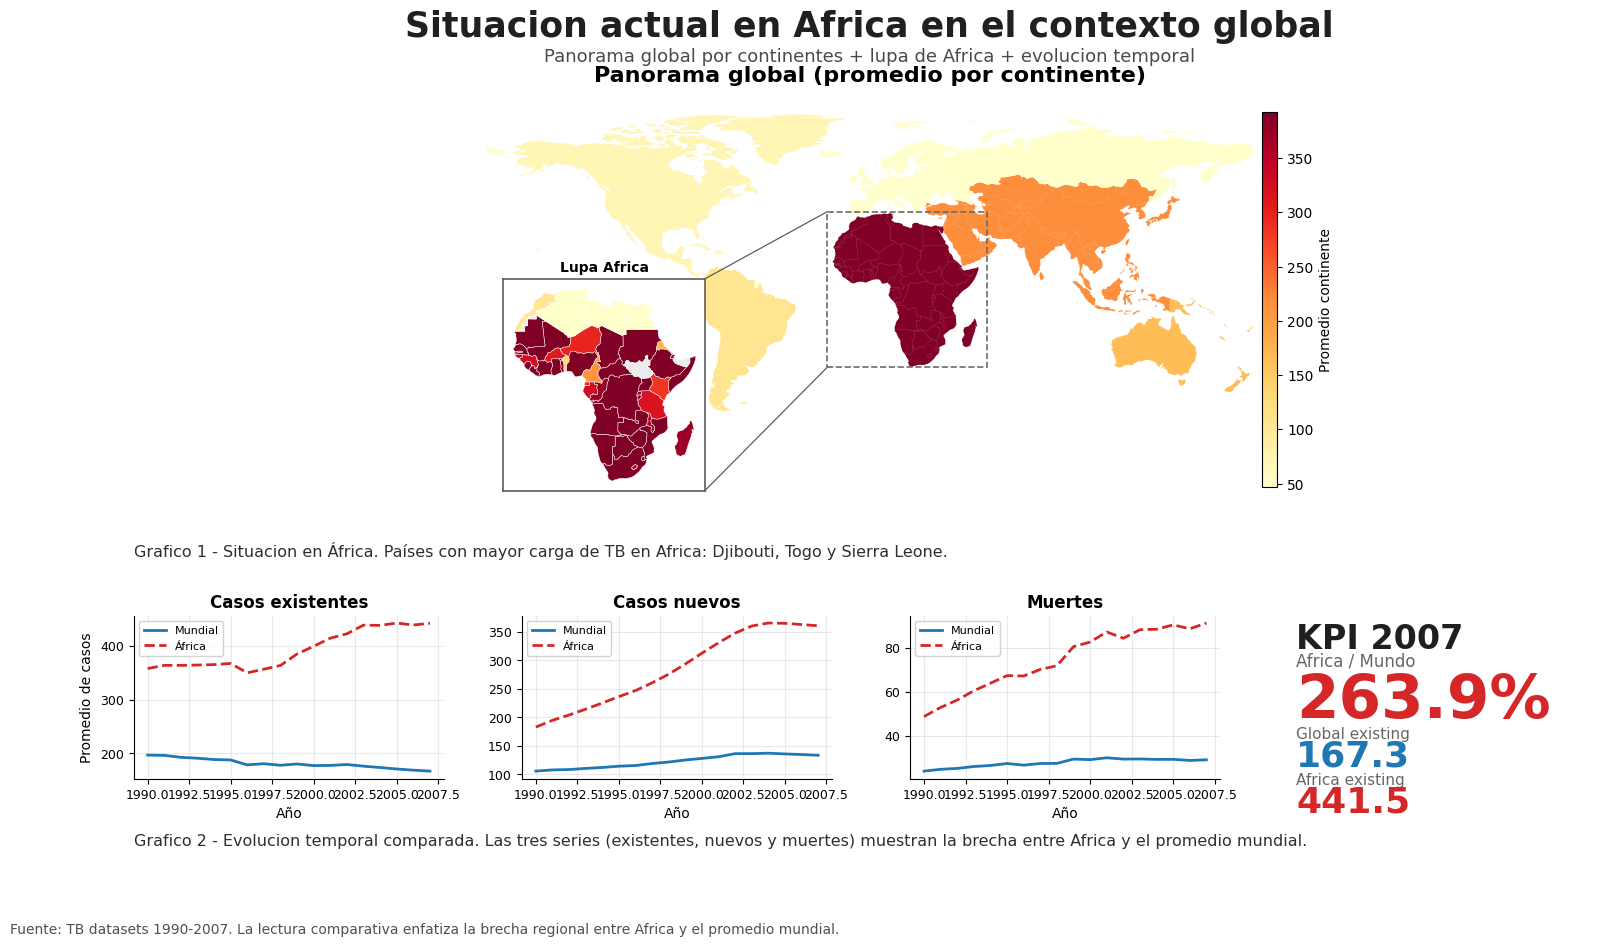

In [41]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
from matplotlib.patches import Rectangle, ConnectionPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import geopandas as gpd
import pycountry

# Mapeo autocontenido pais -> continente para no depender del estado del kernel
continent_en_to_es = {
    'Africa': 'Africa',
    'Asia': 'Asia',
    'Europe': 'Europa',
    'North America': 'Norteamérica',
    'South America': 'Sudamérica',
    'Oceania': 'Oceanía',
}

country_name_fixes = {
    'Cape Verde': 'Cabo Verde',
    'Congo, Dem. Rep.': 'Congo, The Democratic Republic of the',
    'Congo, Rep.': 'Congo',
    "Cote d'Ivoire": "Côte d'Ivoire",
    'Libyan Arab Jamahiriya': 'Libya',
    'Swaziland': 'Eswatini',
    'Korea, Dem. Rep.': "Korea, Democratic People's Republic of",
    'Korea, Rep.': 'Korea, Republic of',
    'Macedonia, FYR': 'North Macedonia',
    'Micronesia, Fed. Sts.': 'Micronesia, Federated States of',
    'West Bank and Gaza': 'Palestine, State of',
}

def country_to_iso3(country_name: str) -> str | None:
    if pd.isna(country_name):
        return None
    normalized = country_name_fixes.get(country_name, country_name)
    try:
        return pycountry.countries.lookup(normalized).alpha_3
    except Exception:
        return None

world_url = 'https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson'
world_geo = gpd.read_file(world_url)
iso_to_continent = world_geo.set_index('ISO_A3')['CONTINENT'].to_dict()

def country_to_continent(country_name: str) -> str | None:
    iso3 = country_to_iso3(country_name)
    if iso3 is None:
        return None
    cont_en = iso_to_continent.get(iso3)
    return continent_en_to_es.get(cont_en)

# -----------------------------
# 1) Preparacion de datos
# -----------------------------
base = df_existing[['year', 'País', 'Casos']].copy()
base['year'] = pd.to_numeric(base['year'], errors='coerce')
base = base.dropna(subset=['year', 'País', 'Casos'])
base['Continente'] = base['País'].map(country_to_continent)
base = base.dropna(subset=['Continente'])

continent_avg = (
    base.groupby('Continente', as_index=False)['Casos']
    .mean()
    .rename(columns={'Casos': 'Promedio_continente'})
)

africa_country_avg = (
    base[base['Continente'] == 'Africa']
    .groupby('País', as_index=False)['Casos']
    .mean()
    .rename(columns={'Casos': 'Promedio_pais'})
)

metric_sources = {
    'Casos existentes': df_existing,
    'Casos nuevos': df_new,
    'Muertes': df_deaths,
}

series_frames = []
for metric_name, df_src in metric_sources.items():
    temp = df_src[['year', 'País', 'Casos']].copy()
    temp['year'] = pd.to_numeric(temp['year'], errors='coerce')
    temp = temp.dropna(subset=['year', 'País', 'Casos'])
    temp['Continente'] = temp['País'].map(country_to_continent)

    world_year = temp.groupby('year', as_index=False)['Casos'].mean()
    world_year['Ámbito'] = 'Mundial'
    world_year['Métrica'] = metric_name

    africa_year = (
        temp[temp['Continente'] == 'Africa']
        .groupby('year', as_index=False)['Casos']
        .mean()
    )
    africa_year['Ámbito'] = 'África'
    africa_year['Métrica'] = metric_name

    series_frames.extend([world_year, africa_year])

evo_df = pd.concat(series_frames, ignore_index=True)

# -----------------------------
# 2) Geometrias y joins
# -----------------------------
world_url = 'https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson'
world_geo = gpd.read_file(world_url)

continent_en_to_es = {
    'Africa': 'Africa',
    'Asia': 'Asia',
    'Europe': 'Europa',
    'North America': 'Norteamérica',
    'South America': 'Sudamérica',
    'Oceania': 'Oceanía',
}

world_geo['Continente'] = world_geo['CONTINENT'].map(continent_en_to_es)
world_plot = world_geo.merge(continent_avg, on='Continente', how='left')
world_plot = world_plot[world_plot['CONTINENT'] != 'Antarctica'].copy()

# Disolver por continente para que no se vean fronteras internas
world_cont = (
    world_plot.dropna(subset=['Continente'])[['Continente', 'Promedio_continente', 'geometry']]
    .dissolve(by='Continente', aggfunc='mean')
    .reset_index()
)

def country_to_iso3(country_name: str) -> str | None:
    if pd.isna(country_name):
        return None
    normalized = country_name_fixes.get(country_name, country_name)
    try:
        return pycountry.countries.lookup(normalized).alpha_3
    except Exception:
        return None


africa_country_avg['ISO_A3'] = africa_country_avg['País'].map(country_to_iso3)
africa_plot = world_geo[world_geo['CONTINENT'] == 'Africa'].merge(
    africa_country_avg[['ISO_A3', 'Promedio_pais']],
    on='ISO_A3',
    how='left'
)

# -----------------------------
# 3) KPIs
# -----------------------------
latest_year = int(evo_df['year'].max())
latest_existing_global = float(
    evo_df[(evo_df['year'] == latest_year) & (evo_df['Ámbito'] == 'Mundial') & (evo_df['Métrica'] == 'Casos existentes')]['Casos'].iloc[0]
)
latest_existing_africa = float(
    evo_df[(evo_df['year'] == latest_year) & (evo_df['Ámbito'] == 'África') & (evo_df['Métrica'] == 'Casos existentes')]['Casos'].iloc[0]
)
share_africa = (latest_existing_africa / latest_existing_global) * 100 if latest_existing_global > 0 else np.nan

top3_africa = africa_country_avg.sort_values('Promedio_pais', ascending=False).head(3)

# -----------------------------
# 4) Layout profesional
# -----------------------------
plt.style.use('default')
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['savefig.transparent'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'

fig = plt.figure(figsize=(19, 11), facecolor='white')
gs = gridspec.GridSpec(
    5,
    4,
    figure=fig,
    height_ratios=[0.08, 0.55, 0.08, 0.22, 0.07],
    width_ratios=[1.0, 1.0, 1.0, 1.0],
    wspace=0.22,
    hspace=0.18
)

ax_title = fig.add_subplot(gs[0, :])
ax_world = fig.add_subplot(gs[1, :])
ax_caption_map = fig.add_subplot(gs[2, :])
bottom_gs = gs[3, :3].subgridspec(1, 3, wspace=0.25)
ax_existing = fig.add_subplot(bottom_gs[0, 0])
ax_new = fig.add_subplot(bottom_gs[0, 1])
ax_deaths = fig.add_subplot(bottom_gs[0, 2])
ax_caption_trend = fig.add_subplot(gs[4, :3])
ax_kpi = fig.add_subplot(gs[3:5, 3])

# Fondo blanco para paneles
for panel_ax in [ax_title, ax_world, ax_caption_map, ax_existing, ax_new, ax_deaths, ax_caption_trend, ax_kpi]:
    panel_ax.patch.set_facecolor('white')
    panel_ax.patch.set_alpha(1.0)

# Titulo
ax_title.axis('off')
ax_title.text(
    0.5,
    0.72,
    'Situacion actual en Africa en el contexto global',
    ha='center',
    va='center',
    fontsize=25,
    fontweight='bold',
    color='#202020'
)
ax_title.text(
    0.5,
    0.22,
    'Panorama global por continentes + lupa de Africa + evolucion temporal',
    ha='center',
    va='center',
    fontsize=13,
    color='#4a4a4a'
)

# Mapa global sin fronteras internas
world_cont.plot(
    column='Promedio_continente',
    cmap='YlOrRd',
    linewidth=0,
    edgecolor='none',
    ax=ax_world,
    zorder=1
)
world_geo.boundary.plot(ax=ax_world, color='white', linewidth=0.15, alpha=0.25, zorder=2)
ax_world.set_title('Panorama global (promedio por continente)', fontsize=16, fontweight='bold', pad=10)

ax_world.axis('off')

# Colorbar global
norm_w = mpl.colors.Normalize(
    vmin=np.nanmin(world_cont['Promedio_continente']),
    vmax=np.nanmax(world_cont['Promedio_continente'])
)
sm_w = mpl.cm.ScalarMappable(norm=norm_w, cmap='YlOrRd')
sm_w.set_array([])
cax_w = inset_axes(ax_world, width='1.8%', height='92%', loc='center right', borderpad=1.0)
cb_w = fig.colorbar(sm_w, cax=cax_w)
cb_w.set_label('Promedio continente', fontsize=10)
cb_w.ax.set_facecolor('white')

# Zona de referencia en Africa dentro del mapa global
africa_box = Rectangle(
    (-20, -35),
    75,
    73,
    fill=False,
    edgecolor='#6b6b6b',
    linewidth=1.2,
    linestyle='--',
    zorder=6
)
ax_world.add_patch(africa_box)

# Inset (lupa) a la izquierda para no tapar Oceania
ax_lupa = inset_axes(
    ax_world,
    width='34%',
    height='52%',
    loc='lower left',
    borderpad=0.9
)
ax_lupa.patch.set_facecolor('white')
ax_lupa.patch.set_alpha(1.0)
africa_plot.plot(
    column='Promedio_pais',
    cmap='YlOrRd',
    vmin=norm_w.vmin,
    vmax=norm_w.vmax,
    linewidth=0.35,
    edgecolor='white',
    ax=ax_lupa,
    missing_kwds={'color': '#ececec'}
)
ax_lupa.set_xticks([])
ax_lupa.set_yticks([])
ax_lupa.set_title('Lupa Africa', fontsize=10, fontweight='bold', pad=5)
for spine in ax_lupa.spines.values():
    spine.set_edgecolor('#5c5c5c')
    spine.set_linewidth(1.2)

# Conectores de la lupa
con_top = ConnectionPatch(
    xyA=(-20, 38), coordsA=ax_world.transData,
    xyB=(1, 1), coordsB=ax_lupa.transAxes,
    color='#5c5c5c', linewidth=0.9
)
con_bottom = ConnectionPatch(
    xyA=(-20, -35), coordsA=ax_world.transData,
    xyB=(1, 0), coordsB=ax_lupa.transAxes,
    color='#5c5c5c', linewidth=0.9
)
fig.add_artist(con_top)
fig.add_artist(con_bottom)

top_lines = '\n'.join([
    f"{i+1}) {r['País']}: {r['Promedio_pais']:.1f}"
    for i, (_, r) in enumerate(top3_africa.iterrows())
])
top_lines_flat = ' | '.join(top_lines.split('\n'))

# Caption del grafico 1 (mapa global + lupa)
ax_caption_map.axis('off')
top_names = ' | '.join(top3_africa['País'].tolist())

names = top3_africa['País'].tolist()
if len(names) == 0:
    names_txt = ''
elif len(names) == 1:
    names_txt = names[0]
elif len(names) == 2:
    names_txt = f'{names[0]} y {names[1]}'
else:
    names_txt = ', '.join(names[:-1]) + f' y {names[-1]}'

ax_caption_map.text(
    0.0,
    0.80,
    'Grafico 1 - Situacion en África. '
    f'Países con mayor carga de TB en Africa: {names_txt}.',
    fontsize=11.5,
    color='#2f2f2f',
    va='top'
)

# Caption del grafico 2 (bloque de 3 series)
ax_caption_trend.axis('off')
ax_caption_trend.text(
    0.0,
    0.45,
    'Grafico 2 - Evolucion temporal comparada. Las tres series (existentes, nuevos y muertes) muestran la brecha entre Africa y el promedio mundial.',
    fontsize=11.5,
    color='#2f2f2f',
    va='top',
    ha='left',
    wrap=False,
    clip_on=False
)


def plot_metric_panel(ax, metric_name, color_world, color_africa):
    d_world = evo_df[(evo_df['Métrica'] == metric_name) & (evo_df['Ámbito'] == 'Mundial')].sort_values('year')
    d_africa = evo_df[(evo_df['Métrica'] == metric_name) & (evo_df['Ámbito'] == 'África')].sort_values('year')

    ax.patch.set_facecolor('white')
    ax.patch.set_alpha(1.0)
    ax.plot(
        d_world['year'],
        d_world['Casos'],
        label='Mundial',
        color=color_world,
        linewidth=2.0,
        linestyle='-',
        markersize=2.6
    )
    ax.plot(
        d_africa['year'],
        d_africa['Casos'],
        label='África',
        color=color_africa,
        linewidth=2.0,
        linestyle='--',
        markersize=2.6
    )

    ax.set_title(metric_name, fontsize=12, fontweight='bold', pad=6)
    ax.set_xlabel('Año', fontsize=10)
    ax.grid(True, color='#d0d0d0', alpha=0.45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=8, loc='best', frameon=True, framealpha=0.85)


plot_metric_panel(ax_existing, 'Casos existentes', '#1f77b4', '#d62728')
plot_metric_panel(ax_new, 'Casos nuevos', '#1f77b4', '#d62728')
plot_metric_panel(ax_deaths, 'Muertes', '#1f77b4', '#d62728')
ax_existing.set_ylabel('Promedio de casos', fontsize=10)

# Panel KPI grande (estilo grafico)
ax_kpi.axis('off')
ax_kpi.text(0.02, 0.97, f'KPI {latest_year}', fontsize=24, fontweight='bold', color='#1f1f1f', va='top')
ax_kpi.text(0.02, 0.85, 'Africa / Mundo', fontsize=12, color='#666666', va='top')
ax_kpi.text(0.02, 0.77, f'{share_africa:.1f}%', fontsize=44, fontweight='bold', color='#d62728', va='top')
ax_kpi.text(0.02, 0.54, 'Global existing', fontsize=11, color='#666666', va='top')
ax_kpi.text(0.02, 0.49, f'{latest_existing_global:.1f}', fontsize=26, fontweight='bold', color='#1f77b4', va='top')
ax_kpi.text(0.02, 0.35, 'Africa existing', fontsize=11, color='#666666', va='top')
ax_kpi.text(0.02, 0.30, f'{latest_existing_africa:.1f}', fontsize=26, fontweight='bold', color='#d62728', va='top')

fig.text(
    0.06,
    0.04,
    'Fuente: TB datasets 1990-2007. La lectura comparativa enfatiza la brecha regional entre Africa y el promedio mundial.',
    fontsize=10,
    color='#505050'
)

plt.show()

En esta infografía se compara África con el promedio mundial de tuberculosis. Arriba se ve un mapa global por continentes y una lupa de África por país para identificar dónde se concentra más carga. Debajo, las tres series temporales muestran que África mantiene niveles más altos que el promedio mundial en casos existentes, casos nuevos y muertes durante gran parte del periodo.

### Evolución temporal mundial de la tuberculósis

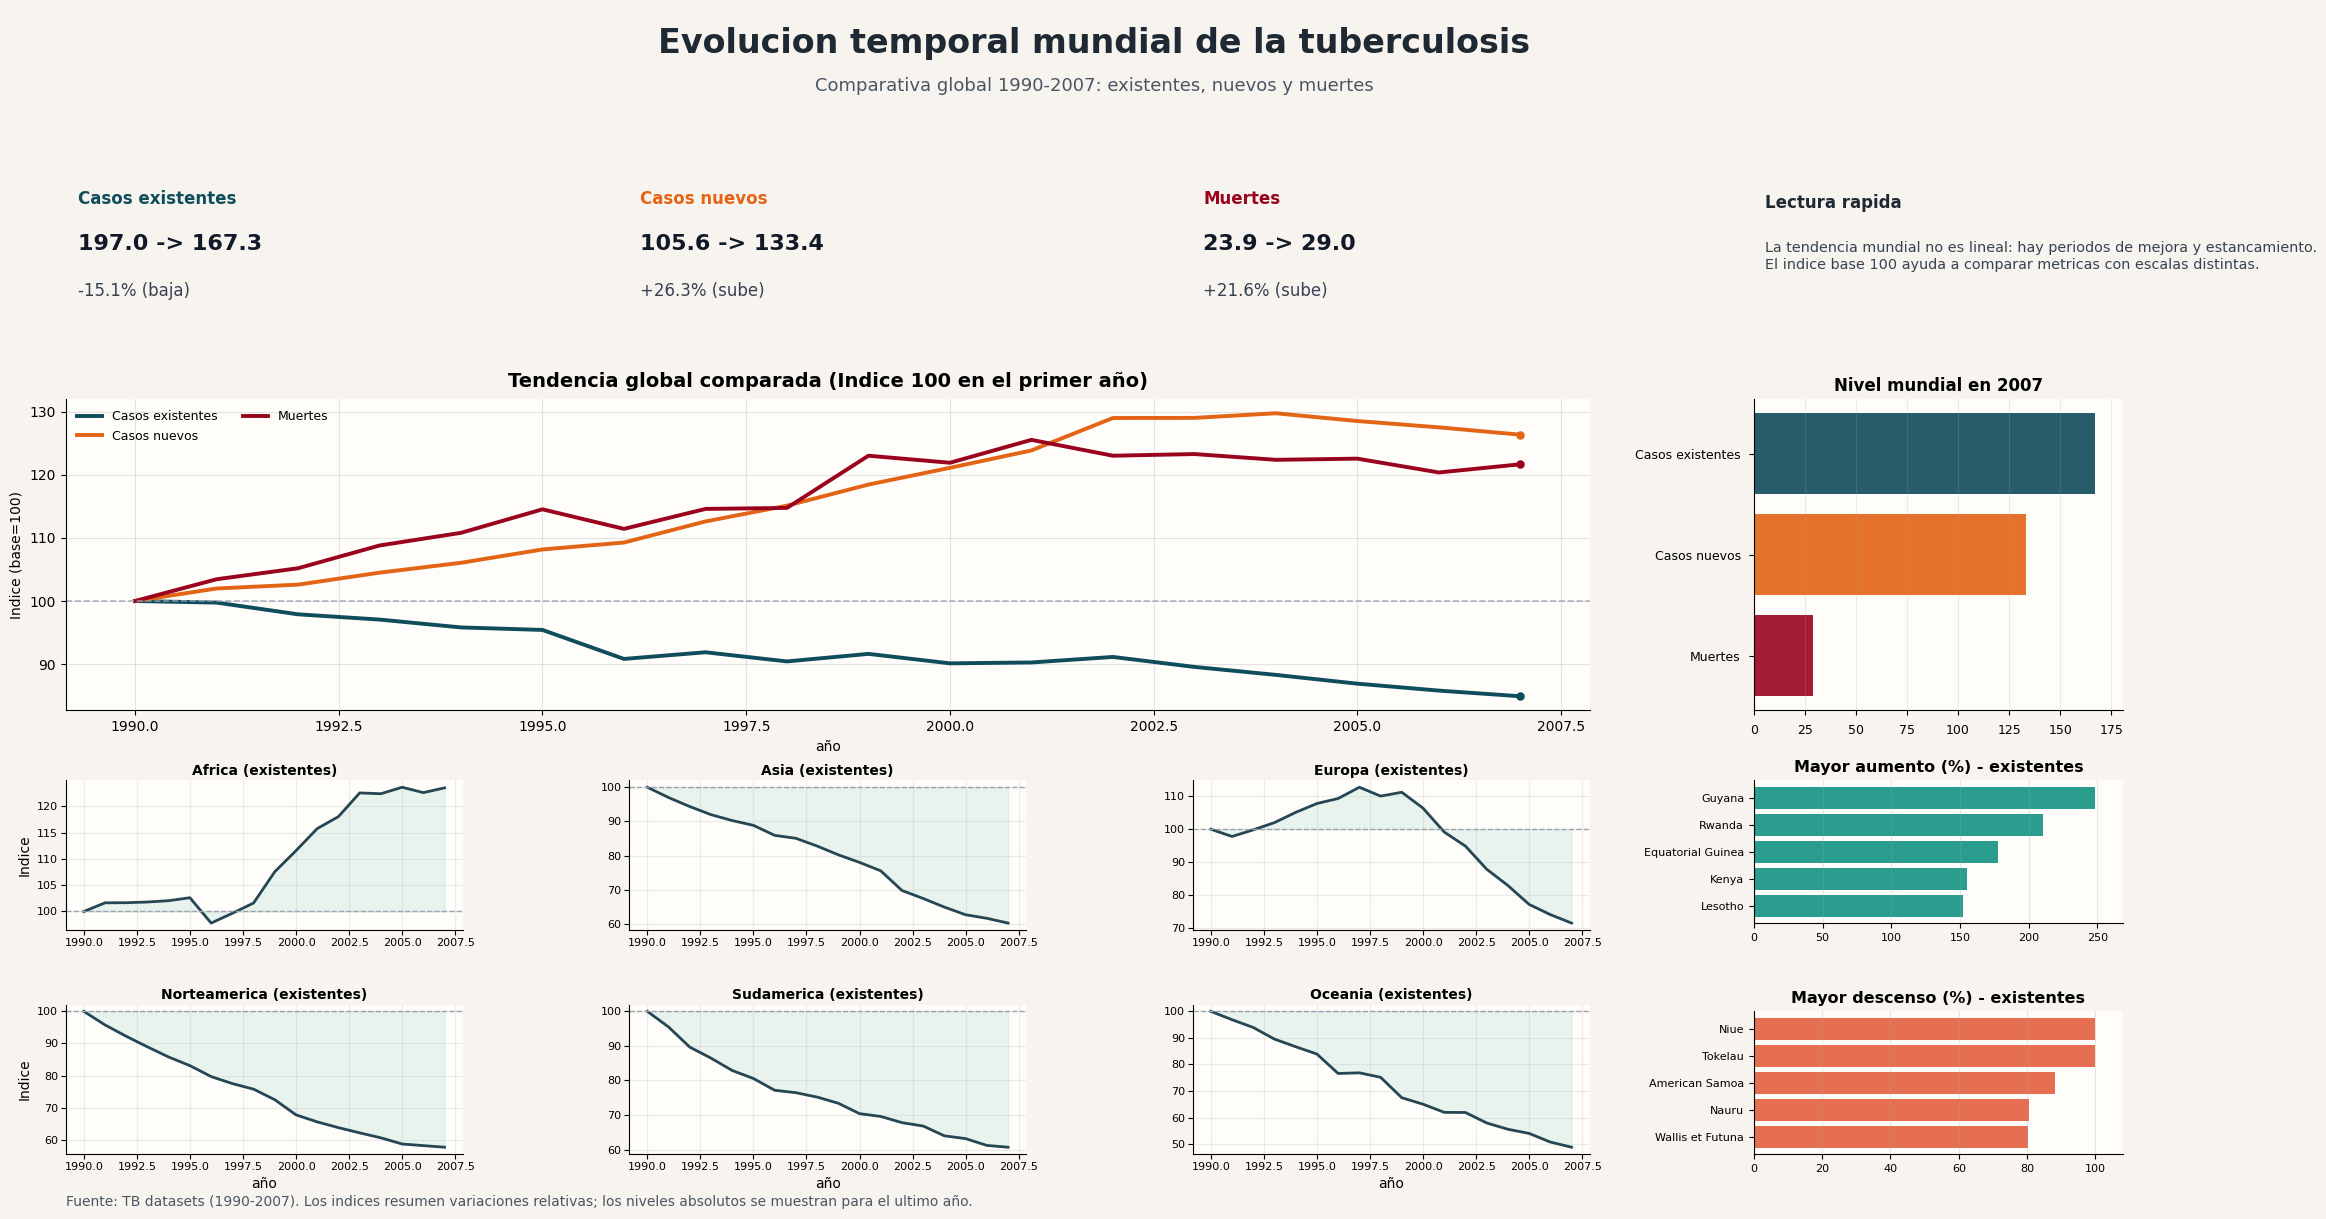

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import gridspec

# ============================================================
# INFOGRAFIA 2: Evolucion temporal mundial de la tuberculosis
# ============================================================

plt.style.use('default')
mpl.rcParams['figure.facecolor'] = '#f7f4ef'
mpl.rcParams['axes.facecolor'] = '#fffdf9'
mpl.rcParams['savefig.facecolor'] = '#f7f4ef'
plt.rcParams['font.family'] = 'DejaVu Sans'

metric_sources = {
    'Casos existentes': df_existing,
    'Casos nuevos': df_new,
    'Muertes': df_deaths,
}
metric_colors = {
    'Casos existentes': '#0f4c5c',
    'Casos nuevos': '#e36414',
    'Muertes': '#9a031e',
}

# Metricas explicitas para el bloque inferior
bottom_metric_name = 'Casos existentes'
bottom_metric_short = 'existentes'

# -----------------------------
# 1) Serie temporal mundial
# -----------------------------
world_frames = []
for metric_name, df_src in metric_sources.items():
    temp = df_src[['year', 'País', 'Casos']].copy()
    temp['year'] = pd.to_numeric(temp['year'], errors='coerce')
    temp = temp.dropna(subset=['year', 'País', 'Casos'])

    world_year = (
        temp.groupby('year', as_index=False)['Casos']
        .mean()
        .rename(columns={'Casos': 'Valor'})
        .sort_values('year')
    )
    world_year['Metrica'] = metric_name

    base0 = world_year['Valor'].iloc[0]
    world_year['Indice_100'] = (world_year['Valor'] / base0) * 100 if base0 != 0 else np.nan

    world_frames.append(world_year)

world_long = pd.concat(world_frames, ignore_index=True)
first_year = int(world_long['year'].min())
last_year = int(world_long['year'].max())

# -----------------------------
# 2) Evolucion por continente (casos existentes)
# -----------------------------
continent_en_to_es = {
    'Africa': 'Africa',
    'Asia': 'Asia',
    'Europe': 'Europa',
    'North America': 'Norteamerica',
    'South America': 'Sudamerica',
    'Oceania': 'Oceania',
}

iso_to_cont_local = None
if 'iso_to_continent' in globals() and isinstance(iso_to_continent, dict):
    iso_to_cont_local = iso_to_continent
elif 'world_geo' in globals():
    try:
        iso_to_cont_local = world_geo.set_index('ISO_A3')['CONTINENT'].to_dict()
    except Exception:
        iso_to_cont_local = None

country_name_fixes_local = globals().get('country_name_fixes', {
    'Cape Verde': 'Cabo Verde',
    'Congo, Dem. Rep.': 'Congo, The Democratic Republic of the',
    'Congo, Rep.': 'Congo',
    "Cote d'Ivoire": "Cote d'Ivoire",
    'Libyan Arab Jamahiriya': 'Libya',
    'Swaziland': 'Eswatini',
    'Korea, Dem. Rep.': "Korea, Democratic People's Republic of",
    'Korea, Rep.': 'Korea, Republic of',
    'Macedonia, FYR': 'North Macedonia',
    'Micronesia, Fed. Sts.': 'Micronesia, Federated States of',
    'West Bank and Gaza': 'Palestine, State of',
})

def country_to_iso3_local(country_name: str):
    if pd.isna(country_name):
        return None
    normalized = country_name_fixes_local.get(country_name, country_name)
    try:
        return pycountry.countries.lookup(normalized).alpha_3
    except Exception:
        return None

def country_to_continent_local(country_name: str):
    if iso_to_cont_local is None:
        return None
    iso3 = country_to_iso3_local(country_name)
    if iso3 is None:
        return None
    cont_en = iso_to_cont_local.get(iso3)
    return continent_en_to_es.get(cont_en)

cont_df = df_existing[['year', 'País', 'Casos']].copy()
cont_df['year'] = pd.to_numeric(cont_df['year'], errors='coerce')
cont_df = cont_df.dropna(subset=['year', 'País', 'Casos'])
cont_df['Continente'] = cont_df['País'].map(country_to_continent_local)
cont_df = cont_df.dropna(subset=['Continente'])

cont_year = (
    cont_df.groupby(['Continente', 'year'], as_index=False)['Casos']
    .mean()
    .rename(columns={'Casos': 'Valor'})
)

# -----------------------------
# 3) KPIs y rankings
# -----------------------------
kpi_rows = []
for metric in metric_sources.keys():
    d = world_long[world_long['Metrica'] == metric].sort_values('year')
    start = float(d['Valor'].iloc[0])
    end = float(d['Valor'].iloc[-1])
    pct = ((end - start) / start) * 100 if start != 0 else np.nan
    kpi_rows.append((metric, start, end, pct))

country_year = (
    df_existing[['year', 'País', 'Casos']]
    .assign(year=lambda x: pd.to_numeric(x['year'], errors='coerce'))
    .dropna(subset=['year', 'País', 'Casos'])
    .groupby(['País', 'year'], as_index=False)['Casos']
    .mean()
)

start_country = country_year[country_year['year'] == first_year][['País', 'Casos']].rename(columns={'Casos': 'inicio'})
end_country = country_year[country_year['year'] == last_year][['País', 'Casos']].rename(columns={'Casos': 'fin'})
change_country = start_country.merge(end_country, on='País', how='inner')
change_country = change_country[change_country['inicio'] > 0].copy()
change_country['pct_change'] = ((change_country['fin'] - change_country['inicio']) / change_country['inicio']) * 100

best5 = change_country.sort_values('pct_change', ascending=False).head(5)
worst5 = change_country.sort_values('pct_change', ascending=True).head(5)

# -----------------------------
# 4) Layout de la infografia
# -----------------------------
fig = plt.figure(figsize=(22, 13), facecolor='#f7f4ef')
outer = gridspec.GridSpec(
    4, 4,
    figure=fig,
    height_ratios=[0.11, 0.17, 0.35, 0.42],
    width_ratios=[1.08, 1.08, 1.08, 1.00],
    hspace=0.30,
    wspace=0.42,
)
fig.subplots_adjust(left=0.05, right=0.985, top=0.94, bottom=0.06)

ax_title = fig.add_subplot(outer[0, :])
ax_kpi1 = fig.add_subplot(outer[1, 0])
ax_kpi2 = fig.add_subplot(outer[1, 1])
ax_kpi3 = fig.add_subplot(outer[1, 2])
ax_text = fig.add_subplot(outer[1, 3])

ax_index = fig.add_subplot(outer[2, :3])
ax_abs = fig.add_subplot(outer[2, 3])

sub_cont = outer[3, :3].subgridspec(2, 3, hspace=0.50, wspace=0.42)
ax_c1 = fig.add_subplot(sub_cont[0, 0])
ax_c2 = fig.add_subplot(sub_cont[0, 1])
ax_c3 = fig.add_subplot(sub_cont[0, 2])
ax_c4 = fig.add_subplot(sub_cont[1, 0])
ax_c5 = fig.add_subplot(sub_cont[1, 1])
ax_c6 = fig.add_subplot(sub_cont[1, 2])
continent_axes = [ax_c1, ax_c2, ax_c3, ax_c4, ax_c5, ax_c6]

rank_sub = outer[3, 3].subgridspec(2, 1, hspace=0.62)
ax_best = fig.add_subplot(rank_sub[0, 0])
ax_worst = fig.add_subplot(rank_sub[1, 0])

for ax in [ax_title, ax_kpi1, ax_kpi2, ax_kpi3, ax_text, ax_index, ax_abs, ax_best, ax_worst] + continent_axes:
    ax.set_facecolor('#fffdf9')

# Titulo
ax_title.axis('off')
ax_title.text(
    0.5, 0.66,
    'Evolucion temporal mundial de la tuberculosis',
    ha='center', va='center', fontsize=24, fontweight='bold', color='#1f2933'
)
ax_title.text(
    0.5, 0.22,
    f'Comparativa global {first_year}-{last_year}: existentes, nuevos y muertes',
    ha='center', va='center', fontsize=13, color='#4b5563'
)

# Tarjetas KPI
kpi_axes = [ax_kpi1, ax_kpi2, ax_kpi3]
for (metric, start, end, pct), ax in zip(kpi_rows, kpi_axes):
    ax.axis('off')
    color = metric_colors[metric]
    trend_word = 'sube' if pct > 0 else 'baja'
    ax.text(0.03, 0.83, metric, fontsize=12, fontweight='bold', color=color)
    ax.text(0.03, 0.52, f'{start:.1f} -> {end:.1f}', fontsize=16, fontweight='bold', color='#111827')
    ax.text(0.03, 0.22, f'{pct:+.1f}% ({trend_word})', fontsize=12, color='#374151')

ax_text.axis('off')
ax_text.text(0.03, 0.80, 'Lectura rapida', fontsize=12, fontweight='bold', color='#1f2933')
ax_text.text(
    0.03, 0.58,
    'La tendencia mundial no es lineal: hay periodos de mejora y estancamiento.\n'
    'El indice base 100 ayuda a comparar metricas con escalas distintas.',
    fontsize=10.4, color='#374151', va='top'
)

# Grafico principal: indice base 100
for metric in metric_sources.keys():
    d = world_long[world_long['Metrica'] == metric].sort_values('year')
    ax_index.plot(
        d['year'], d['Indice_100'],
        color=metric_colors[metric],
        linewidth=2.8,
        label=metric,
    )
    ax_index.scatter(d['year'].iloc[-1], d['Indice_100'].iloc[-1], color=metric_colors[metric], s=26, zorder=4)

ax_index.axhline(100, color='#9ca3af', linestyle='--', linewidth=1.2, alpha=0.8)
ax_index.set_title('Tendencia global comparada (Indice 100 en el primer año)', fontsize=14, fontweight='bold', pad=9)
ax_index.set_xlabel('año')
ax_index.set_ylabel('Indice (base=100)')
ax_index.grid(True, alpha=0.28, color='#9ca3af')
ax_index.spines['top'].set_visible(False)
ax_index.spines['right'].set_visible(False)
ax_index.legend(frameon=False, ncol=2, loc='upper left', fontsize=9)

# Grafico auxiliar: valores absolutos ultimo año
latest_abs = world_long[world_long['year'] == last_year].copy()
latest_abs = latest_abs.sort_values('Valor', ascending=True)
ax_abs.barh(
    latest_abs['Metrica'], latest_abs['Valor'],
    color=[metric_colors[m] for m in latest_abs['Metrica']],
    alpha=0.9
)
max_abs = float(latest_abs['Valor'].max()) if len(latest_abs) else 1.0
ax_abs.set_xlim(0, max_abs * 1.08)
ax_abs.set_title(f'Nivel mundial en {last_year}', fontsize=12, fontweight='bold')
ax_abs.grid(axis='x', alpha=0.22, color='#9ca3af')
ax_abs.spines['top'].set_visible(False)
ax_abs.spines['right'].set_visible(False)
ax_abs.tick_params(labelsize=9, pad=6)

# Small multiples por continente
cont_order = ['Africa', 'Asia', 'Europa', 'Norteamerica', 'Sudamerica', 'Oceania']
for ax, cont in zip(continent_axes, cont_order):
    d = cont_year[cont_year['Continente'] == cont].sort_values('year')
    if d.empty:
        ax.axis('off')
        continue

    base_c = d['Valor'].iloc[0]
    d = d.copy()
    d['Indice_100'] = (d['Valor'] / base_c) * 100 if base_c != 0 else np.nan

    ax.plot(d['year'], d['Indice_100'], color='#264653', linewidth=2.0)
    ax.fill_between(d['year'], d['Indice_100'], 100, color='#2a9d8f', alpha=0.10)
    ax.axhline(100, color='#9ca3af', linestyle='--', linewidth=1.0)
    ax.set_title(f'{cont} ({bottom_metric_short})', fontsize=10.0, fontweight='bold', pad=4)
    ax.grid(True, alpha=0.20, color='#9ca3af')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8, pad=2)

ax_c1.set_ylabel('Indice')
ax_c4.set_ylabel('Indice')
ax_c4.set_xlabel('año')
ax_c5.set_xlabel('año')
ax_c6.set_xlabel('año')

# Rankings finales
best_plot = best5.sort_values('pct_change', ascending=True)
worst_plot = worst5.assign(descenso_abs=worst5['pct_change'].abs()).sort_values('descenso_abs', ascending=True)

ax_best.barh(best_plot['País'], best_plot['pct_change'], color='#2a9d8f')
max_best = float(best_plot['pct_change'].max()) if len(best_plot) else 1.0
ax_best.set_xlim(0, max_best * 1.08)
ax_best.set_title(f'Mayor aumento (%) - {bottom_metric_short}', fontsize=11.5, fontweight='bold', pad=6)
ax_best.grid(axis='x', alpha=0.25, color='#9ca3af')
ax_best.spines['top'].set_visible(False)
ax_best.spines['right'].set_visible(False)
ax_best.tick_params(labelsize=8)

ax_worst.barh(worst_plot['País'], worst_plot['descenso_abs'], color='#e76f51')
max_worst = float(worst_plot['descenso_abs'].max()) if len(worst_plot) else 1.0
ax_worst.set_xlim(0, max_worst * 1.08)
ax_worst.set_title(f'Mayor descenso (%) - {bottom_metric_short}', fontsize=11.5, fontweight='bold', pad=6)
ax_worst.grid(axis='x', alpha=0.25, color='#9ca3af')
ax_worst.spines['top'].set_visible(False)
ax_worst.spines['right'].set_visible(False)
ax_worst.tick_params(labelsize=8)

fig.text(
    0.05, 0.02,
    'Fuente: TB datasets (1990-2007). Los indices resumen variaciones relativas; los niveles absolutos se muestran para el ultimo año.',
    fontsize=10,
    color='#4b5563'
)

plt.show()

Esta infografía resume la evolución mundial entre 1990 y 2007 para casos existentes, casos nuevos y muerte. En la parte inferior se ven diferencias por continente y un ranking de países con mayores aumentos y descensos porcentuales en casos existentes.